# ***Mnist***

In [ ]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()

11490434/11490434 [==============================] - 1s 0us/step


![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/interp.gif)

**We will normalize all values between 0 and 1 and we will flatten the 28x28 images into vectors of size 784.**

In [ ]:
x_train[0].shape

(28, 28)

In [ ]:

x_train = x_train/255.0
x_test = x_test/255.0
x_train.shape

(60000, 28, 28)

In [ ]:
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print (x_train.shape)
print (x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
28*28

784

In [ ]:
len(x_train[0])

784


#  **First AutoEncoder**

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model


In the context of deep learning we refer to autoencoders (AEs) as neural networks where the expected output coincides with the input and the architecture contains a bottleneck (see figure below). The bottleneck favour a precise behaviour; the first part of the AE, or **Encoder**, learns to distill the information useful to *distinguish* between input samples, a **latent code** sized as the limited bottleneck. This latent code is then taken in input by the second part of the network, the **Decoder**, which tries to reconstruct the original input. To accomplish this result, the Decoder should learn all the information about the domain of the data not useful to distinguish between samples, but needed to reconstruct them. The loss of a standard AE is simply a reconstruction loss, e.g. in the case of an image it is a comparison of each pixel, tipically with a cross-entropy.

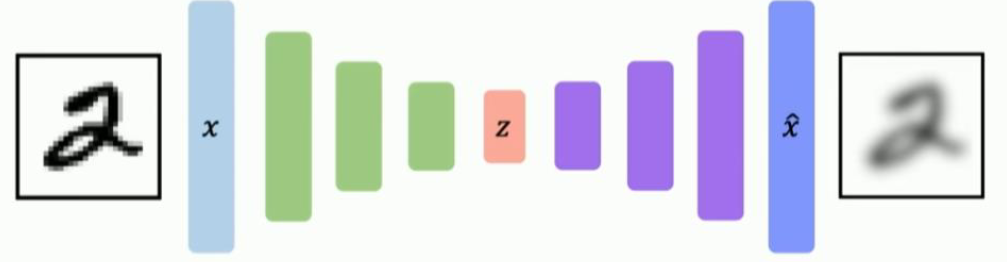

In [ ]:


# this is the size of our encoded representations
encoding_dim = 10  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = Dense('''TODO''')('''TOD''')

# this model maps an input to its reconstruction
autoencoder = Model('''TODO''')

Let's also create a separate encoder model:
this model maps an input to its encoded representation


In [ ]:
encoder = Model('''TODO''')

As well as the decoder model:

In [ ]:
# create a placeholder for an encoded (32-dimensional) input
encoded_input = Input(shape=(encoding_dim,))
# retrieve the last layer of the autoencoder model
decoder_layer = '''TODO'''
# create the decoder model
decoder = Model('''TODO''')

Now let's train our autoencoder to reconstruct MNIST digits.

First, we'll configure our model to use a per-pixel binary crossentropy loss, and the Adadelta optimizer:

In [ ]:
autoencoder.compile('''TODO''')

In [ ]:
autoencoder.fit('''TODO''')

We can try to visualize the reconstructed inputs and the encoded representationslib.

In [ ]:
# encode and decode some digits
# note that we take them from the *test* set
encoded_imgs = encoder.predict('''TODO''')
decoded_imgs = decoder.predict('''TODO''')

In [ ]:
# use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.gray()
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

#  **ConvNet for AutoEncoder**





In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model


input_img = Input(shape=(28, 28, 1))  # adapt this if using `channels_first` image data format

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (4, 4, 8) i.e. 128-dimensional

x = Conv2D('''TODO''')('''TODO''')
x = UpSampling2D('''TODO''')(x)
x = Conv2D('''TODO''')(x)
x = UpSampling2D('''TODO''')(x)
x = Conv2D('''TODO''')(x)
x = UpSampling2D('''TODO''')(x)
decoded = Conv2D('''TODO''')(x)

autoencoder = Model('''TODO''')
autoencoder.compile('''TODO''')

In [ ]:
autoencoder.summary()

Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_12 (Conv2D)          (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 14, 14, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 14, 8)         1160      
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 7, 7, 8)           0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 7, 7, 8)           584 

In [ ]:
x_train.shape

(60000, 28, 28)

In [ ]:
autoencoder.fit('''TODO''')

313/313 [==============================] - 1s 2ms/step


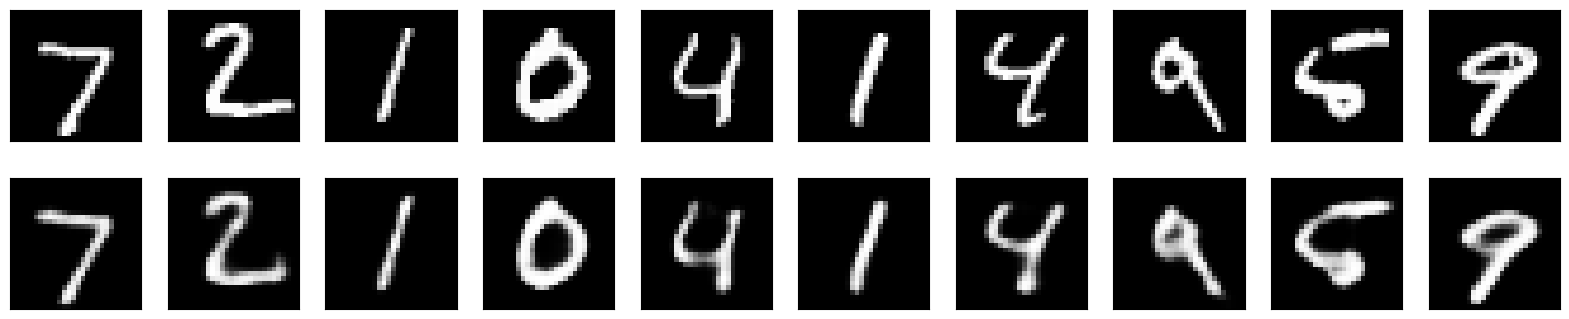

In [ ]:
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i +1+ n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# **Sparse AutoEncoder**




In [ ]:
from keras import regularizers

encoding_dim = 32

input_img = Input(shape=(784,))
# add a Dense layer with a L1 activity regularizer
encoded = Dense(encoding_dim, activation='relu',
                activity_regularizer=regularizers.l1(10e-4))(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)

In [ ]:
# create a placeholder for an encoded (32-dimensional) input
encoded_input = Input(shape=(encoding_dim,))
# retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# create the decoder model
decoder = Model(encoded_input, decoder_layer(encoded_input))
encoder = Model(input_img, encoded)

In [ ]:
autoencoder.compile(optimizer='nadam', loss='mse')


In [ ]:
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/20
235/235 [==============================] - 2s 5ms/step - loss: 0.1114 - val_loss: 0.0683
Epoch 2/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0610 - val_loss: 0.0565
Epoch 3/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0542 - val_loss: 0.0514
Epoch 4/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0497 - val_loss: 0.0475
Epoch 5/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0463 - val_loss: 0.0446
Epoch 6/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0438 - val_loss: 0.0425
Epoch 7/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0420 - val_loss: 0.0408
Epoch 8/20
235/235 [==============================] - 1s 4ms/step - loss: 0.0405 - val_loss: 0.0395
Epoch 9/20
235/235 [==============================] - 1s 5ms/step - loss: 0.0393 - val_loss: 0.0384
Epoch 10/20
235/235 [==============================] - 1s 6ms/step - loss: 0.0383 - val_loss: 0.0375

In [ ]:
# encode and decode some digits
# note that we take them from the *test* set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 [==============================] - 1s 3ms/step


In [ ]:
encoded_imgs[0]

array([0.28981704, 0.        , 0.        , 0.05912775, 0.        ,
       0.23262021, 0.        , 0.        , 0.53743076, 0.        ,
       1.6339598 , 1.1395516 , 0.11866674, 0.        , 0.        ,
       0.        , 0.22696969, 0.06620497, 0.        , 0.63775873,
       0.        , 0.        , 0.        , 0.        , 1.4718229 ,
       0.        , 0.        , 0.80116236, 0.        , 0.        ,
       0.18947333, 0.03712171], dtype=float32)

In [ ]:

print(sum(encoded_imgs[0]==0))
print(sum(decoded_imgs[0]==0))


18
0


313/313 [==============================] - 1s 3ms/step


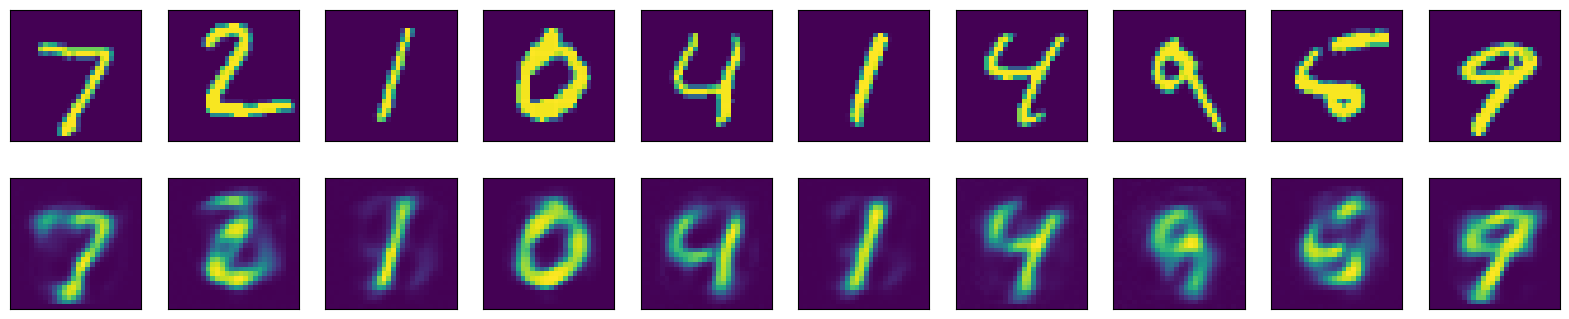

In [ ]:
# use Matplotlib (don't ask)
import matplotlib.pyplot as plt
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)
n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()



313/313 [==============================] - 1s 3ms/step


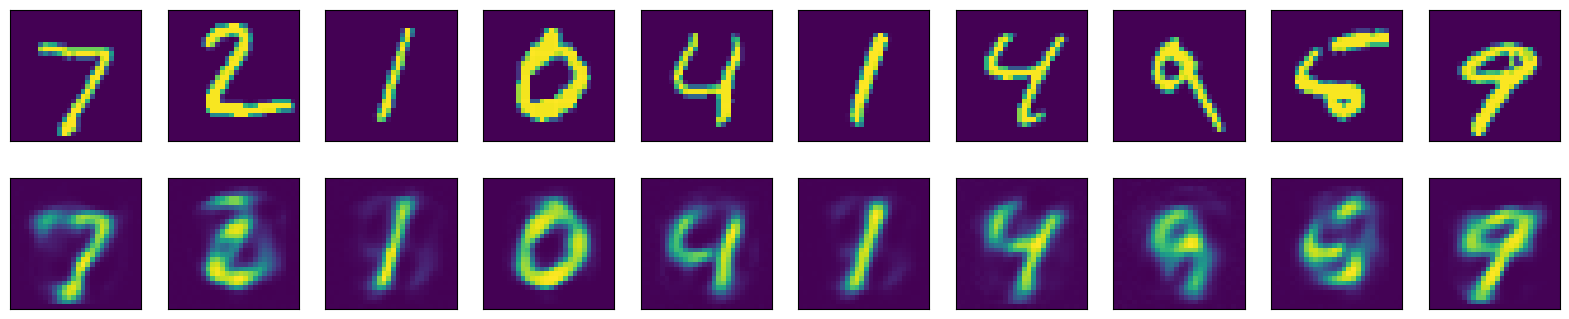

In [ ]:
# use Matplotlib (don't ask)
import matplotlib.pyplot as plt
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)
n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


#  **Denoising AutoEncoder**

Denoising is one of the classic applications of autoencoders. The denoising process removes unwanted noise that corrupted the true signal.
Noise + Data ----> Denoising Autoencoder ----> Data.
Given a training dataset of corrupted data as input and true signal as output, a denoising autoencoder can recover the hidden structure to generate clean data. This example has modular design. The encoder, decoder and autoencoder are
3 models that share weights. For example, after training the autoencoder, the
encoder can be used to generate latent vectors of input data for low-dim visualization like PCA or TSNE.

Generate corrupted MNIST images by adding noise with normal distribution (mean = 0.0 and std= ) to your x_train and x_test dataset.

In [ ]:
from keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))  # adapt this if using `channels_first` image data format
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))  # adapt this if using `channels_first` image data format

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)



After adding the random generated noises to the x sets, keep only those
among 0 and 1 using np.clip()/.

In [ ]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

it looks like

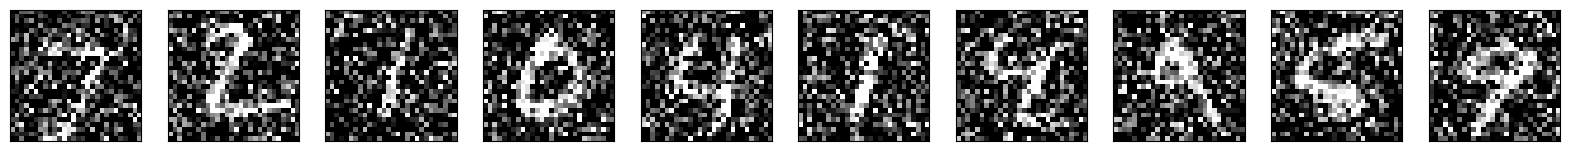

In [ ]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Now build autoencoder to denoise images : use noised data in train to predict original images

In [ ]:
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, UpSampling2D

input_img = Input(shape=(28, 28, 1))  # adapt this if using `channels_first` image data format

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (7, 7, 32)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model('''TODO''')
autoencoder.compile('''TODO''')

In [ ]:
autoencoder.summary()

Model: "model_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_19 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 14, 14, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_20 (Conv2D)          (None, 14, 14, 32)        9248      
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 7, 7, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_21 (Conv2D)          (None, 7, 7, 32)          9248

In [ ]:
autoencoder.fit('''TODO''')

we compare now

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i +1+ n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# ****Variational AutoEncoder****

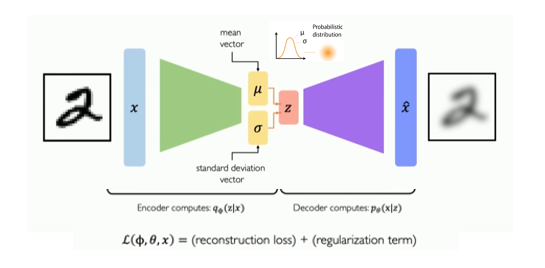

Rather than directly outputting values for the latent state as we would in a standard AE, the encoder model of a VAE outputs entire probability distributions, during training we sample from these distributions to obtain a latent code for the decoder.

Traditional **VAEs make the strong assumption on the distribution of latent codes as a multivariate Gaussian with a diagonal covariance structure**, so each component is normally distributed and indipendent from the others.

A $n$-dimensional gaussian is defined by a vector $(\mu_1, ... , \mu_n)$ and a covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$. Since we are assuming independent components, $\Sigma$ is a diagonal matrix and we can describe it with a single vector of size $n$ containing the diagonal. Furthermore, the boundary of the Gaussian will assume a spherical shape (in the general case of arbitrary covariance matrices, it assumes an ellipsoidal shape).

So the Encoder of a VAE outputs two vectors collecting the means and the variances (instead of encoding the variance $\sigma^2$ we will work for convenience with the logarithm of the variance $log(\sigma^2)$).



**Intuition: encoding probability distributions**

Let's suppose we've trained an autoencoder model on a large dataset of faces with a encoding dimension of 6. An ideal autoencoder will learn descriptive attributes of faces such as skin color, whether or not the person is wearing glasses, etc. in an attempt to describe an observation in some compressed representation.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int1.png)

In the example above, we've described the input image in terms of its latent attributes using a **single value to describe each attribute**.

However, we may prefer to represent each latent attribute as a range of possible values. For instance, what *single value* would you assign for the smile attribute if you feed in a photo of the Mona Lisa? Using a variational autoencoder, we can describe latent attributes in probabilistic terms.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int2.png)


With this approach, we'll now represent each latent attribute for a given input as a probability distribution. When decoding from the latent state, we'll randomly sample from each latent state distribution to generate a vector as input for our decoder model.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int3.png)

By constructing our encoder model to output a range of possible values (a statistical distribution) from which we'll randomly sample to feed into our decoder model, we're essentially enforcing a continuous, smooth latent space representation. For any sampling of the latent distributions, we're expecting our decoder model to be able to accurately reconstruct the input. Thus, values which are nearby to one another in latent space should correspond with very similar reconstructions.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int4.png)


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow import keras

E + STD*Epsilon

STD = sqrt(V)

In [ ]:
def Sampling(args):
    z_mean, z_log_var = args
    batch = keras.backend.shape(z_mean)[0]
    dim = keras.backend.int_shape(z_mean)[1]
    epsilon = keras.backend.random_normal(shape=(batch, dim))
    return z_mean + keras.backend.exp(0.5 * z_log_var) * epsilon


In [ ]:
#Build the encoder
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()('''TODO''')
encoder = keras.Model(encoder_inputs, '''TODO''', name="encoder")
encoder.summary()


In [ ]:
#Build the decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


In [ ]:
# Define the VAE as a Model with a custom train_step

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


In [ ]:
# Train the VAE

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE('''TODO''')
vae.compile('''TODO''')
vae.fit('''TODO''')


In [ ]:
# Display a grid of sampled digits

import matplotlib.pyplot as plt


def plot_latent_space(vae, n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(vae)


In [ ]:
from sklearn.manifold import TSNE
def plot_latent_space(z_mean,y):

    # Réduction de dimension avec t-SNE
    tsne = TSNE(n_components=2, init='pca')
    zmean_tsne = tsne.fit_transform(z_mean)


    fig, ax = plt.subplots()
    cmap = plt.get_cmap("tab10")  # Utilisez une carte de couleurs pour différencier les classes
    unique_labels = np.unique(y)
    # Tracer les points pour chaque classe
    for t in unique_labels:
        points = zmean_tsne[y == t]
        ax.scatter(points[:, 0], points[:, 1], color=cmap(t), label=t)

    ax.legend()  # Ajouter une légende
    plt.xlabel('t-SNE caractéristique 1')  # Étiquette pour l'axe x
    plt.ylabel('t-SNE caractéristique 2')  # Étiquette pour l'axe y
    plt.title('Visualisation de l\'espace latent')  # Titre du graphique

    plt.show()  # Afficher le graphique

In [ ]:
z_mean, _, _ = vae.encoder.predict(x_test)
plot_latent_space(z_mean,y_test )

1875/1875 [==============================] - 3s 2ms/step


<ipython-input-43-02d7d402f295>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap("tab10", len(np.unique(labels)))
<ipython-input-43-02d7d402f295>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(z_mean[indices, 0], z_mean[indices, 1], c=colormap(label), label=label)


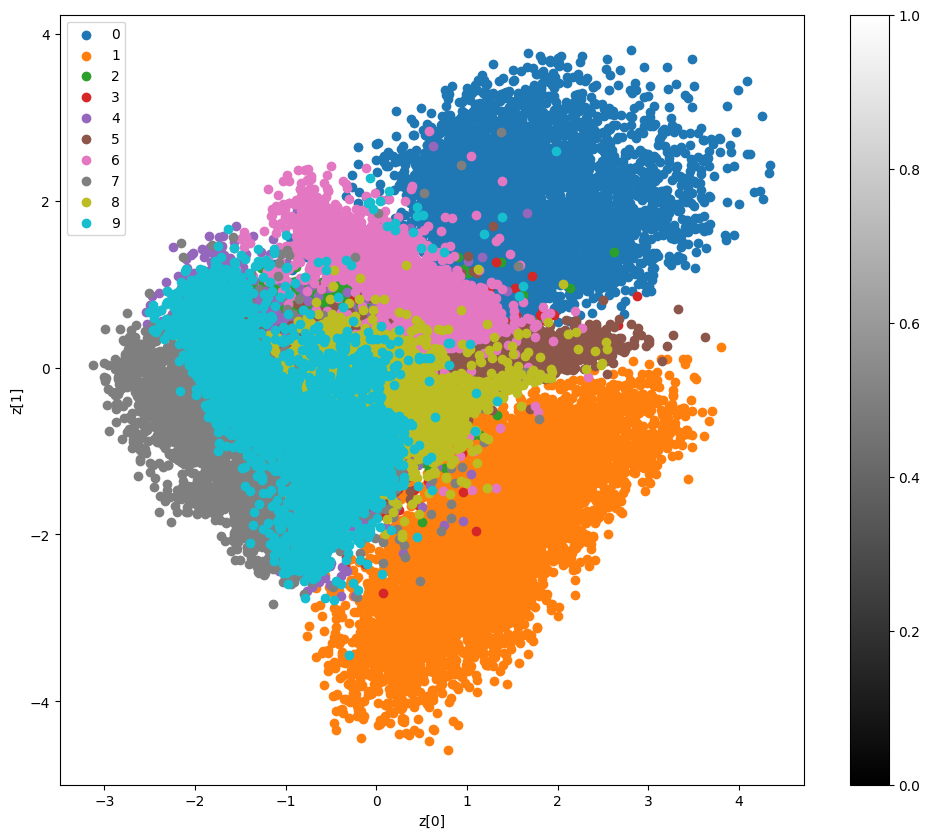

In [ ]:

def plot_label_clusters(vae, data, labels):
    # Display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data)
    plt.figure(figsize=(12, 10))
    # Define a colormap
    colormap = plt.cm.get_cmap("tab10", len(np.unique(labels)))
    # Plot each data point with a color corresponding to its label
    for label in np.unique(labels):
        indices = labels == label
        plt.scatter(z_mean[indices, 0], z_mean[indices, 1], c=colormap(label), label=label)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.legend()
    plt.show()

(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, -1).astype("float32") / 255

plot_label_clusters(vae, x_train, y_train)